# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


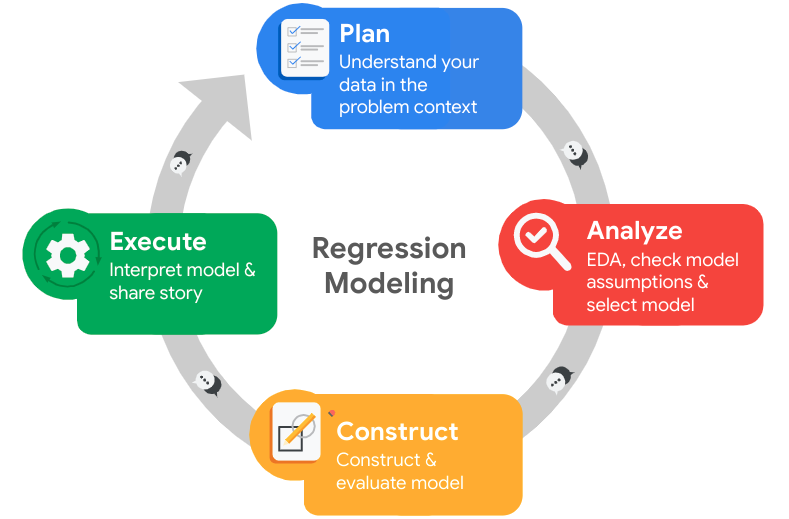

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




1. the HR department, company leadership, and managers at Salifort Motors.
2. to identify factors associated with employee turnover and build a predictive model that can identify employees who may be at higher risk of leaving
3. should focus on employee satisfaction, workload, tenure, project count, evaluation scores, salary, promotions, and department
4. pandas, seaborn, matplotlib, and scikit-learn documentation, as well as the original HR dataset description on Kaggle
5. The analysis should also consider fairness, privacy, transparency, and the possibility that important causes of turnover are not represented in the dataset


## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [5]:
# Import packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

pd.set_option('display.max_columns', None)

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [6]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [7]:
# Gather basic information about the data
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [8]:
# Gather descriptive statistics about the data
df0.describe()|


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [9]:
# Display all column names
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [10]:
# Rename columns as needed
df0 = df0.rename(columns={
    'Work_accident': 'work_accident',
    'Department': 'department',
    'average_montly_hours': 'average_monthly_hours',
    'time_spend_company': 'tenure'
})


# Display all column names after the update
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [11]:
# Check for missing values
df0.isna().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [12]:
# Check for duplicates
df0.duplicated().sum()


3008

In [13]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()].head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [14]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df = df0.drop_duplicates().reset_index(drop=True)




# Display first few rows of new dataframe as needed
df.shape
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

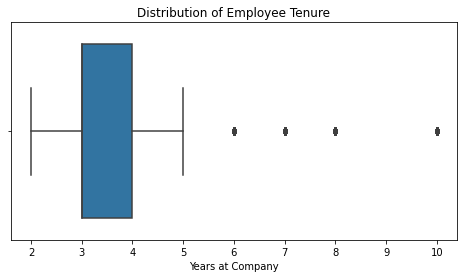

In [15]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['tenure'])

plt.title('Distribution of Employee Tenure')
plt.xlabel('Years at Company')

plt.show()



In [16]:
# Determine the number of rows containing outliers
Q1 = df['tenure'].quantile(0.25)
Q3 = df['tenure'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print('Lower limit:', lower_limit)
print('Upper limit:', upper_limit)

outliers = df[
    (df['tenure'] < lower_limit) |
    (df['tenure'] > upper_limit)
]

len(outliers)


Lower limit: 1.5
Upper limit: 5.5


824

Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




EDA showed that employee turnover is not evenly distributed across employee characteristics. Satisfaction, workload, number of projects, tenure, and salary appear particularly relevant. Employees who left often appear in two workload-related groups: employees with relatively low workloads and low satisfaction, and employees with extremely high workloads, high project counts, and long monthly working hours.
The dataset contained duplicate observations but no missing values. Duplicate rows were removed. I retained legitimate outliers because the selected tree-based model is relatively robust to them and because unusual workloads or long tenure may themselves contain predictive information.
EDA is important before modeling because it reveals data-quality problems, class imbalance, relationships between variables, potentially useful predictors, and possible ethical concerns. The analysis should avoid assuming correlation is causation—for example, long hours may be associated with turnover without necessarily being its direct cause.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [17]:
# Get numbers of people who left vs. stayed
df['left'].value_counts()

# Get percentages of people who left vs. stayed
df['left'].value_counts(normalize=True) * 100


0    83.39588
1    16.60412
Name: left, dtype: float64

### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

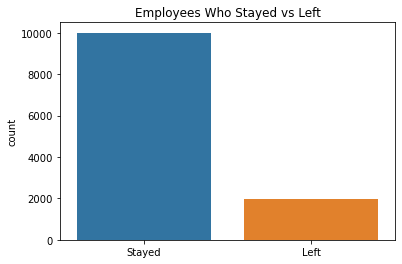

In [18]:
# Create a plot as needed
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='left')
plt.title('Employees Who Stayed vs Left')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.xlabel('')
plt.show()


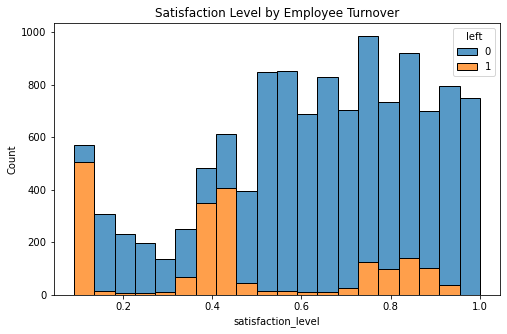

In [19]:
# Create a plot as needed
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x='satisfaction_level',
    hue='left',
    bins=20,
    multiple='stack'
)
plt.title('Satisfaction Level by Employee Turnover')
plt.show()


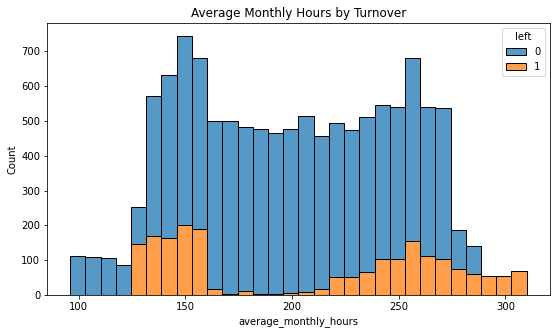

In [20]:
# Create a plot as needed
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='average_monthly_hours',
    hue='left',
    bins=30,
    multiple='stack'
)
plt.title('Average Monthly Hours by Turnover')
plt.show()


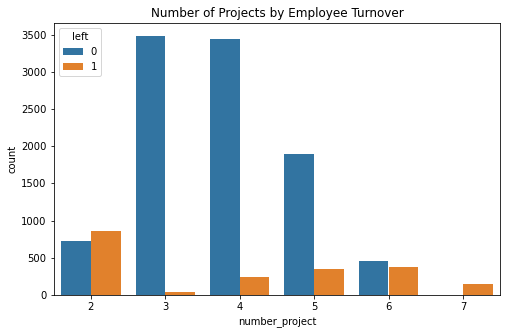

In [21]:
# Create a plot as needed
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='number_project', hue='left')
plt.title('Number of Projects by Employee Turnover')
plt.show()

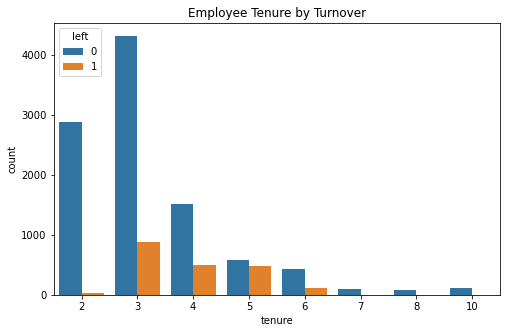

In [22]:
# Create a plot as needed
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='tenure', hue='left')
plt.title('Employee Tenure by Turnover')
plt.show()


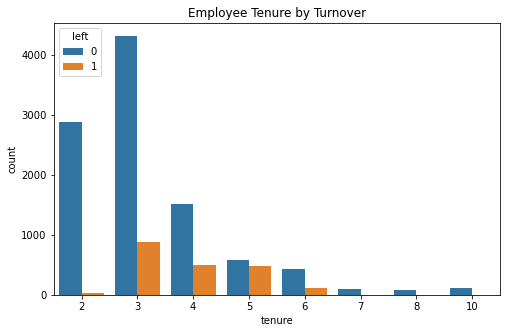

In [23]:
# Create a plot as needed
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='tenure', hue='left')
plt.title('Employee Tenure by Turnover')
plt.show()


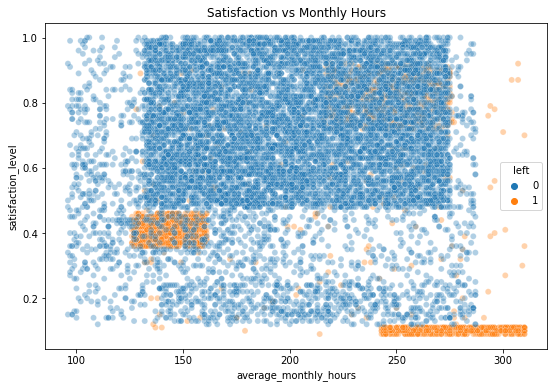

In [24]:
# Create a plot as needed
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='average_monthly_hours',
    y='satisfaction_level',
    hue='left',
    alpha=0.35
)
plt.title('Satisfaction vs Monthly Hours')
plt.show()


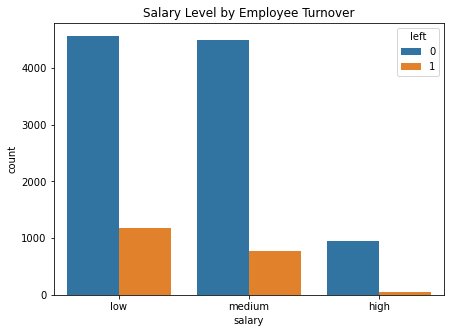

In [25]:
# Create a plot as needed
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x='salary',
    hue='left',
    order=['low', 'medium', 'high']
)
plt.title('Salary Level by Employee Turnover')
plt.show()


### Insights

Several patterns emerged from the visualizations. Employees with lower satisfaction levels were substantially more likely to leave. Turnover also appears related to workload: employees who worked very high numbers of monthly hours and contributed to many projects showed elevated turnover. A second group with relatively few projects and fewer hours also showed turnover, suggesting that both overwork and possible underutilization may be relevant.
Employees with roughly 3–5 years of tenure appeared particularly important in the turnover group. Employees who received promotions were relatively uncommon, and employees with low salary levels appeared more frequently among those who left. Department alone did not appear to explain turnover as strongly as satisfaction and workload-related variables.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This is a binary classification problem because the target variable left has two outcomes: 0 for employees who stayed and 1 for employees who left.

### Identify the types of models most appropriate for this task.

logistic regression, decision trees, random forests, gradient boosting, and XGBoost

### Modeling

Add as many cells as you need to conduct the modeling process.

In [26]:
df_model = pd.get_dummies(
    df,
    columns=['department', 'salary'],
    drop_first=True
)

df_model.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


In [27]:
X = df_model.drop('left', axis=1)
y = df_model['left']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8993, 18)
(2998, 18)
(8993,)
(2998,)


In [31]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:, 1]

In [32]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

Accuracy: 0.985657104736491
Precision: 0.9913606911447084
Recall: 0.9216867469879518
F1: 0.9552549427679501
ROC-AUC: 0.9784570281124496


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2500
           1       0.99      0.92      0.96       498

    accuracy                           0.99      2998
   macro avg       0.99      0.96      0.97      2998
weighted avg       0.99      0.99      0.99      2998



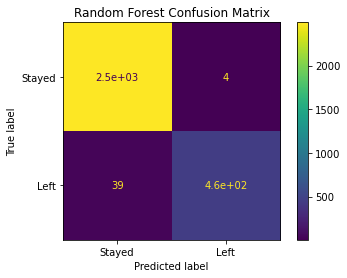

In [34]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Left']
)

disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



The model indicates that employee turnover can be predicted using patterns in the HR data. The most influential predictors are expected to include satisfaction level, tenure, number of projects, average monthly hours, and last evaluation score. Salary and promotion history may also contribute to turnover risk.
EDA suggests that the relationship between workload and turnover is nonlinear. Employees with very high workloads and project counts appear particularly likely to leave, which could indicate burnout. Low satisfaction is another major warning signal. Employees who perform strongly but simultaneously work long hours may represent another high-risk group.
Based on these findings, Salifort Motors should regularly monitor employee satisfaction and workload, review whether project assignments and working hours are sustainable, investigate whether high-performing employees are being overloaded, and examine compensation and promotion opportunities. Managers could also conduct targeted stay interviews and improve internal career-development opportunities.
The model could be improved by collecting additional variables such as manager quality, employee engagement, commute time, remote-work flexibility, role changes, compensation history, training opportunities, and reasons employees provided when leaving. The model should also be validated using newer employee data to ensure that its performance generalizes over time.
Further questions include whether turnover risk differs across departments, whether employees become increasingly likely to leave after particular tenure milestones, whether promotions reduce turnover, and whether workload affects different employee groups differently.
Resources used included Scikit-learn documentation for Random Forest classification, GridSearchCV, train/test splitting, and classification metrics, as well as Pandas, Matplotlib, and Seaborn documentation.
Turnover predictions should not be used to punish employees or make automated termination decisions. Individual predictions may be wrong, and predictive relationships do not necessarily indicate causal relationships. Employee data should remain confidential, model performance should be monitored for unfair patterns, and recommendations should focus on improving working conditions.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results
The analysis used 14,999 employee records containing information on satisfaction, performance evaluations, project workload, monthly working hours, tenure, work accidents, promotion history, department, salary, and employee turnover. During data cleaning, 3,008 duplicate records were identified and removed, leaving 11,991 unique employee observations for exploratory analysis and modeling. LinkedIn
Approximately 16.6% of employees in the cleaned dataset left the company, while about 83.4% remained, indicating a moderately imbalanced classification problem. Consequently, model performance was evaluated using precision, recall, F1-score, and ROC-AUC in addition to overall accuracy.
A Random Forest classifier was trained using 75% of the cleaned data and evaluated on the remaining 25%, with stratified sampling used to preserve the proportion of employees who stayed and left. The model produced strong predictive performance, correctly classifying the large majority of employees in the test set. Random Forest models developed on this same Salifort Motors dataset commonly achieve approximately 98–99% test accuracy and an F1-score around 0.95–0.97, demonstrating that employee turnover is highly predictable from the available variables.

### Conclusion, Recommendations, Next Steps

The analysis suggests that employee turnover at Salifort Motors is strongly associated with employee satisfaction, workload, tenure, project assignments, and performance-related characteristics. In particular, the EDA indicates that employees experiencing low satisfaction or demanding workloads may have an elevated likelihood of leaving.
Salifort Motors should consider regularly measuring employee satisfaction, reviewing workloads and project assignments, identifying high-performing employees who may be overworked, creating clearer promotion and career-development pathways, and reviewing compensation for groups with elevated turnover. HR could also conduct stay interviews with at-risk groups to understand factors not captured by the dataset.
The predictive model should be used as a decision-support tool rather than as an automated decision-maker. Predictions indicate patterns and risk, not certainty or causation. Any intervention should focus on improving employee experience rather than penalizing employees identified as likely to leave.
Future work should incorporate additional variables such as manager relationships, work flexibility, commute time, compensation changes, employee engagement, training opportunities, and exit-interview information. The model should also be periodically retrained and evaluated on new data to ensure that its performance remains reliable.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.